In [1]:
import subprocess, sys
for pkg in ['scipy', 'matplotlib', 'pandas', 'numpy', 'tqdm', 'pyarrow']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import warnings
from itertools import combinations
from math import comb
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

## 0. Load Data

In [3]:
returns_all = pd.read_parquet("sp500_returns.parquet")
print(f"Loaded: {returns_all.shape[0]} trading days x {returns_all.shape[1]} tickers")
print(f"Date range: {returns_all.index[0].date()} -> {returns_all.index[-1].date()}")

Loaded: 2854 trading days x 462 tickers
Date range: 2015-01-05 -> 2026-05-11


In [ ]:

# ── fig0: Data overview ────────────────────────────────────────────────────────
import scipy.stats as sp_stats

fig, axes = plt.subplots(3, 1, figsize=(13, 15))
fig.subplots_adjust(hspace=0.42)

# Panel A: Cumulative wealth (arithmetic) — NVDA excluded (scale distortion)
ax = axes[0]
showcase = ['AAPL', 'MSFT', 'JPM', 'JNJ', 'XOM', 'WMT']
showcase = [t for t in showcase if t in returns_all.columns]
colors_sc = plt.cm.tab10.colors
for idx, t in enumerate(showcase):
    wealth = (1 + returns_all[t].fillna(0)).cumprod()
    ax.plot(returns_all.index, wealth, label=t, linewidth=1.4, color=colors_sc[idx])
ax.axhline(1, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative Wealth (initial $1)', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Wealth ($)')
ax.legend(fontsize=9, ncol=6)
ax.grid(True, alpha=0.25)

# Panel B: Risk–return scatter for all 462 stocks
ax = axes[1]
ann_mu_all  = returns_all.mean() * 252
ann_vol_all = returns_all.std()  * np.sqrt(252)
ew_mu_val   = float(returns_all.mean(axis=1).mean() * 252)
ew_vol_val  = float(returns_all.mean(axis=1).std()  * np.sqrt(252))
ax.scatter(ann_vol_all * 100, ann_mu_all * 100,
           alpha=0.35, s=10, color='steelblue', label='Individual stocks')
ax.scatter(ew_vol_val * 100, ew_mu_val * 100,
           color='crimson', s=90, zorder=5, marker='*',
           label='Equal-weight portfolio')
ax.set_title('Risk–Return Tradeoff (annualised, N=462)', fontsize=12)
ax.set_xlabel('Volatility (%)')
ax.set_ylabel('Expected Return (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# Panel C: Histogram of daily returns for AAPL vs fitted Normal
ax = axes[2]
ticker_hist = 'AAPL' if 'AAPL' in returns_all.columns else returns_all.columns[0]
r_daily = returns_all[ticker_hist].dropna() * 100
ax.hist(r_daily, bins=90, density=True, alpha=0.55,
        color='steelblue', label=f'{ticker_hist} daily returns')
x_grid = np.linspace(r_daily.min(), r_daily.max(), 400)
ax.plot(x_grid,
        sp_stats.norm.pdf(x_grid, float(r_daily.mean()), float(r_daily.std())),
        'r-', linewidth=2, label='Normal fit')
sk = float(sp_stats.skew(r_daily))
ku = float(sp_stats.kurtosis(r_daily))
ax.set_title(f'Daily Return Distribution ({ticker_hist}) — skew={sk:.2f}, excess kurt={ku:.2f}', fontsize=12)
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

fig.savefig('fig0_data_overview.png', dpi=130, bbox_inches='tight')
plt.show()
print("fig0_data_overview.png saved.")

# Cross-sectional descriptive statistics
desc_mu   = ann_mu_all * 100
desc_vol  = ann_vol_all * 100
desc_skew = returns_all.apply(lambda x: sp_stats.skew(x.dropna()))
desc_kurt = returns_all.apply(lambda x: sp_stats.kurtosis(x.dropna()))

print("\nCross-sectional descriptive statistics (N=462 stocks):")
print(f"{'Statistic':22s}  {'Min':>7} {'Q25':>7} {'Median':>7} {'Mean':>7} {'Q75':>7} {'Max':>7}")
for name, s in [('Ann. return  (%)', desc_mu),
                ('Ann. vol     (%)', desc_vol),
                ('Daily skewness',   desc_skew),
                ('Excess kurtosis',  desc_kurt)]:
    qs = np.percentile(s, [0, 25, 50, 75, 100])
    print(f"{name:22s}  {qs[0]:7.2f} {qs[1]:7.2f} {qs[2]:7.2f} "
          f"{float(s.mean()):7.2f} {qs[3]:7.2f} {qs[4]:7.2f}")


## 1. Universe & Parameters

In [4]:
# Load all available tickers — no manual selection
rets_raw = returns_all.copy()

# ── NaN diagnostics ───────────────────────────────────────────────────────
nan_pct = rets_raw.isna().mean() * 100
bad = nan_pct[nan_pct > 20].index.tolist()
if bad:
    print(f"Dropping high-NaN tickers (>20%): {len(bad)} tickers")
    rets_raw = rets_raw.drop(columns=bad)

rets = rets_raw.dropna()
print(f"Tickers: {rets.shape[1]}  |  Rows kept after dropna: {len(rets)} / {len(rets_raw)}  "
      f"({100*len(rets)/len(rets_raw):.1f}%)")

if len(rets) < 100:
    raise ValueError(f"Only {len(rets)} rows after dropna — data issue.")

T, N = rets.shape
tickers   = list(rets.columns)
mu_all    = rets.mean().values * 252
Sigma_all = rets.cov().values  * 252

# ── Return sanity check ───────────────────────────────────────────────────
print(f"\nAnnualised return range:")
for i in [mu_all.argmin(), mu_all.argmax()]:
    print(f"  {tickers[i]:6s}: {mu_all[i]:.2%}")
print(f"  Mean  : {mu_all.mean():.2%}")
if np.any(~np.isfinite(mu_all)):
    raise ValueError("NaN or Inf in mu_all — data issue upstream.")

# ── Risk budget ───────────────────────────────────────────────────────────
var_individual = np.diag(Sigma_all)
SIGMA_SQ_MAX = np.percentile(var_individual, 25)

w_mkt   = np.ones(N) / N
var_mkt = w_mkt @ Sigma_all @ w_mkt

print(f"\nN={N}, T={T}  (T/N = {T/N:.1f})")
print(f"Market vol (ann.):        {np.sqrt(var_mkt):.2%}")
print(f"Individual vol range:     {np.sqrt(var_individual.min()):.2%} – {np.sqrt(var_individual.max()):.2%}")
print(f"Risk limit sigma_0:       {np.sqrt(SIGMA_SQ_MAX):.2%}  (25th pct of stock vols)")


Tickers: 462  |  Rows kept after dropna: 2854 / 2854  (100.0%)

Annualised return range:
  VTRS  : -1.56%
  NVDA  : 65.67%
  Mean  : 16.19%

N=462, T=2854  (T/N = 6.2)
Market vol (ann.):        18.06%
Individual vol range:     17.76% – 68.45%
Risk limit sigma_0:       25.64%  (25th pct of stock vols)


## 2. Optimization Primitives

In [5]:
# ── Closed-form Markowitz inner solver (short selling allowed, no w >= 0) ─
def socp_inner(mu_s, Sigma_s, sigma_sq_max):
    """
    Closed-form solution to:
        max  mu_s @ w
        s.t. w @ Sigma_s @ w <= sigma_sq_max,   1 @ w = 1
    Short selling is allowed (no non-negativity constraint).

    Uses the Markowitz efficient frontier formula (two-fund separation):
        w* = (1/D) * [(C - B*mu*) * Sigma^-1 @ 1  +  (A*mu* - B) * Sigma^-1 @ mu]
    where A = 1'Sigma^-1*1, B = 1'Sigma^-1*mu, C = mu'Sigma^-1*mu, D = AC - B^2,
    and the optimal return is:
        mu* = B/A + sqrt(D/A * (sigma_sq_max - 1/A))

    Returns (w*, optimal_return) or (None, None) if infeasible
    (sigma_sq_max is below the global min-variance 1/A for this subset).
    """
    k = len(mu_s)
    ones = np.ones(k)

    if k == 1:
        if Sigma_s[0, 0] <= sigma_sq_max + 1e-12:
            return np.array([1.0]), float(mu_s[0])
        return None, None

    try:
        Sigma_inv = np.linalg.inv(Sigma_s)
    except np.linalg.LinAlgError:
        return None, None

    si1 = Sigma_inv @ ones      # Sigma^-1 @ 1
    sim = Sigma_inv @ mu_s      # Sigma^-1 @ mu

    A = float(ones @ si1)       # 1' Sigma^-1 1
    B = float(ones @ sim)       # 1' Sigma^-1 mu
    C = float(mu_s @ sim)       # mu' Sigma^-1 mu
    D = A * C - B * B           # discriminant (> 0 when Sigma PD, mu not const*1)

    # Guard: near-singular Sigma_s → A ≈ 0, can't compute min-variance
    if A < 1e-14:
        return None, None

    # Degenerate: all returns identical → any feasible portfolio achieves same return
    if D < 1e-14:
        sigma_sq_min = 1.0 / A
        if sigma_sq_max >= sigma_sq_min - 1e-10:
            return si1 / A, float(mu_s[0])
        return None, None

    sigma_sq_min = 1.0 / A      # global min-variance achievable for this subset

    if sigma_sq_max < sigma_sq_min - 1e-10:
        return None, None       # infeasible: risk budget below min-variance

    # Optimal return on the efficient frontier at variance level sigma_sq_max
    mu_star = B / A + np.sqrt(D / A * max(sigma_sq_max - sigma_sq_min, 0.0))

    # Two-fund separation weights
    w_star = (1.0 / D) * ((C - B * mu_star) * si1 + (A * mu_star - B) * sim)

    return w_star, float(mu_star)


def solve_subset(idx, mu, Sigma, sigma_sq_max):
    """Solve the inner Markowitz problem for the asset subset given by idx."""
    idx = list(idx)
    return socp_inner(mu[idx], Sigma[np.ix_(idx, idx)], sigma_sq_max)


# ── Full Markowitz upper bound (all N assets, no cardinality) ─────────────
def socp_upper_bound(mu, Sigma, sigma_sq_max):
    """
    Closed-form Markowitz solution over all N assets (no cardinality, no w>=0).
    Identical to socp_inner; kept as a named wrapper for clarity.
    """
    return socp_inner(mu, Sigma, sigma_sq_max)


print("Solvers defined — closed-form Markowitz, short selling allowed.")


Solvers defined — closed-form Markowitz, short selling allowed.


## 3. SOCP Upper Bound (No Cardinality Constraint)

Markowitz upper bound return : 120.2391%
Portfolio volatility         : 25.6433%  (limit = 25.6433%)
Long positions (w > 0.1%)    : 231 / 462
Short positions (w < -0.1%)  : 224 / 462


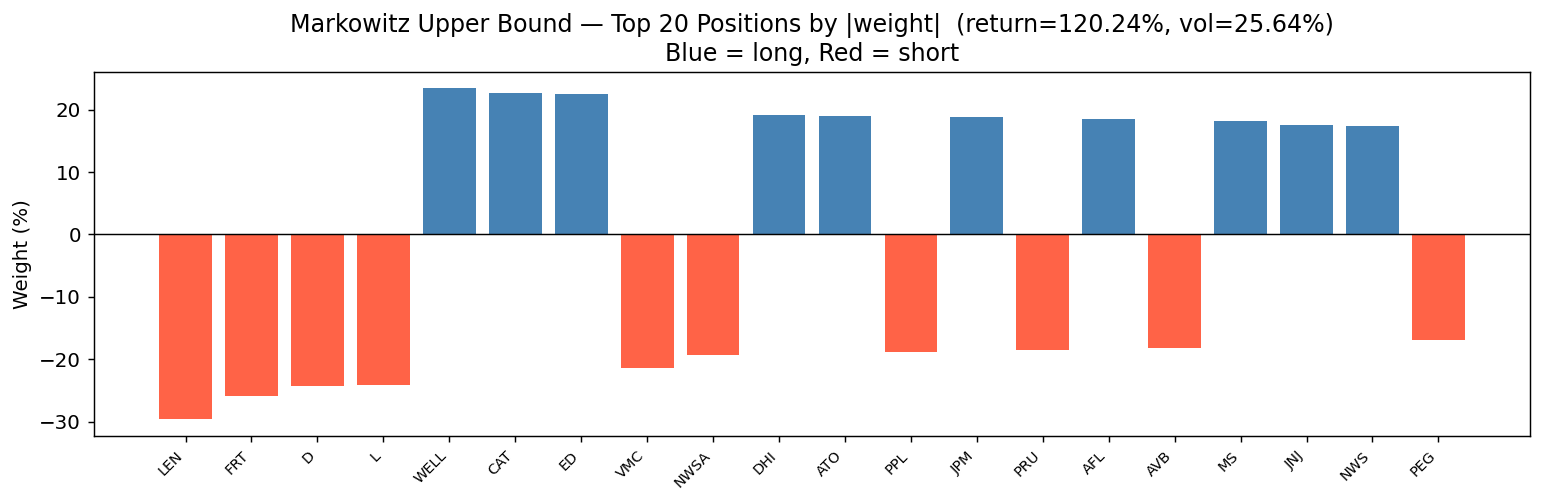

In [6]:
w_ub, ret_ub = socp_upper_bound(mu_all, Sigma_all, SIGMA_SQ_MAX)

if w_ub is None:
    print("Markowitz upper bound: INFEASIBLE — sigma_sq_max is below the global min-variance.")
    print(f"  sigma_0 = {np.sqrt(SIGMA_SQ_MAX):.2%}.  Try raising SIGMA_SQ_MAX.")
else:
    vol_ub   = np.sqrt(w_ub @ Sigma_all @ w_ub)
    n_long   = int((w_ub >  1e-3).sum())
    n_short  = int((w_ub < -1e-3).sum())

    print(f"Markowitz upper bound return : {ret_ub:.4%}")
    print(f"Portfolio volatility         : {vol_ub:.4%}  (limit = {np.sqrt(SIGMA_SQ_MAX):.4%})")
    print(f"Long positions (w > 0.1%)    : {n_long} / {N}")
    print(f"Short positions (w < -0.1%)  : {n_short} / {N}")

    top_n = min(20, N)
    top_idx = np.argsort(np.abs(w_ub))[::-1][:top_n]   # sort by |weight|
    colors = ['steelblue' if w_ub[i] >= 0 else 'tomato' for i in top_idx]
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(top_n), w_ub[top_idx] * 100, color=colors)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(range(top_n))
    ax.set_xticklabels([tickers[i] for i in top_idx], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel("Weight (%)")
    ax.set_title(f"Markowitz Upper Bound — Top {top_n} Positions by |weight|  "
                 f"(return={ret_ub:.2%}, vol={vol_ub:.2%})\n"
                 f"Blue = long, Red = short")
    plt.tight_layout()
    plt.savefig("fig1_socp_weights.png")
    plt.show()


## 4. Algorithms

In [7]:
def brute_force(n, k, mu, Sigma, sigma_sq_max, max_combos=100_000):
    total = comb(n, k)
    if total > max_combos:
        return None, None, total, None
    best_ret, best_sub = -np.inf, None
    t0 = time.time()
    for sub in combinations(range(n), k):
        _, ret = solve_subset(sub, mu, Sigma, sigma_sq_max)
        if ret is not None and ret > best_ret:
            best_ret, best_sub = ret, sub
    return best_sub, best_ret, total, time.time() - t0

def greedy(n, k, mu, Sigma, sigma_sq_max):
    t0 = time.time()
    selected, candidates = [], list(range(n))
    for _ in range(k):
        best_ret, best_asset = -np.inf, None
        for a in candidates:
            _, ret = solve_subset(selected + [a], mu, Sigma, sigma_sq_max)
            if ret is not None and ret > best_ret:
                best_ret, best_asset = ret, a
        if best_asset is None:
            break
        selected.append(best_asset)
        candidates.remove(best_asset)
    _, final_ret = solve_subset(selected, mu, Sigma, sigma_sq_max)
    return selected, final_ret, time.time() - t0

def simulated_annealing(n, k, mu, Sigma, sigma_sq_max,
                         n_steps=2000, T_start=0.004, T_end=5e-5, n_restarts=3):
    import math

    # k == n: only one possible subset — no swaps, return immediately
    if k >= n:
        sub = list(range(n))
        _, ret = solve_subset(sub, mu, Sigma, sigma_sq_max)
        ret = ret if ret is not None else -np.inf
        return sub, ret, np.full(n_steps + 1, ret)

    best_overall_ret, best_overall_sub = -np.inf, None
    avg_history = np.zeros(n_steps + 1)
    for _ in range(n_restarts):
        state = sorted(np.random.choice(n, k, replace=False).tolist())
        not_in = [i for i in range(n) if i not in state]
        _, cur_ret = solve_subset(state, mu, Sigma, sigma_sq_max)
        cur_ret = cur_ret if cur_ret is not None else -np.inf
        best_ret, best_state = cur_ret, state[:]
        history = [best_ret]
        for step in range(n_steps):
            if not not_in:          # no swap candidates — stop early
                history.extend([best_ret] * (n_steps - step))
                break
            T = T_start * (T_end / T_start) ** (step / n_steps)
            out_pos = np.random.randint(k)
            in_asset = int(np.random.choice(not_in))
            new_state = state[:]
            removed = new_state[out_pos]
            new_state[out_pos] = in_asset
            new_state = sorted(new_state)
            new_not_in = [i for i in not_in if i != in_asset] + [removed]
            _, new_ret = solve_subset(new_state, mu, Sigma, sigma_sq_max)
            new_ret = new_ret if new_ret is not None else -np.inf
            delta = new_ret - cur_ret
            if delta > 0 or (T > 1e-10 and np.random.random() < math.exp(max(delta / T, -500))):
                state, not_in, cur_ret = new_state, new_not_in, new_ret
                if new_ret > best_ret:
                    best_ret, best_state = new_ret, new_state[:]
            history.append(best_ret)
        avg_history += np.array(history)
        if best_ret > best_overall_ret:
            best_overall_ret, best_overall_sub = best_ret, best_state[:]
    avg_history /= n_restarts
    return best_overall_sub, best_overall_ret, avg_history

print("Algorithms defined.")


Algorithms defined.


## 5. Experiment A — Search Space & Runtime Scaling

Timing brute force (k=5):
  n=10: C(n,5)=252  time=0.0s
  n=15: C(n,5)=3,003  time=0.1s


  n=20: C(n,5)=15,504  time=0.5s


  n=25: C(n,5)=53,130  time=1.8s


  n=30: C(n,5)=142,506  time=4.9s


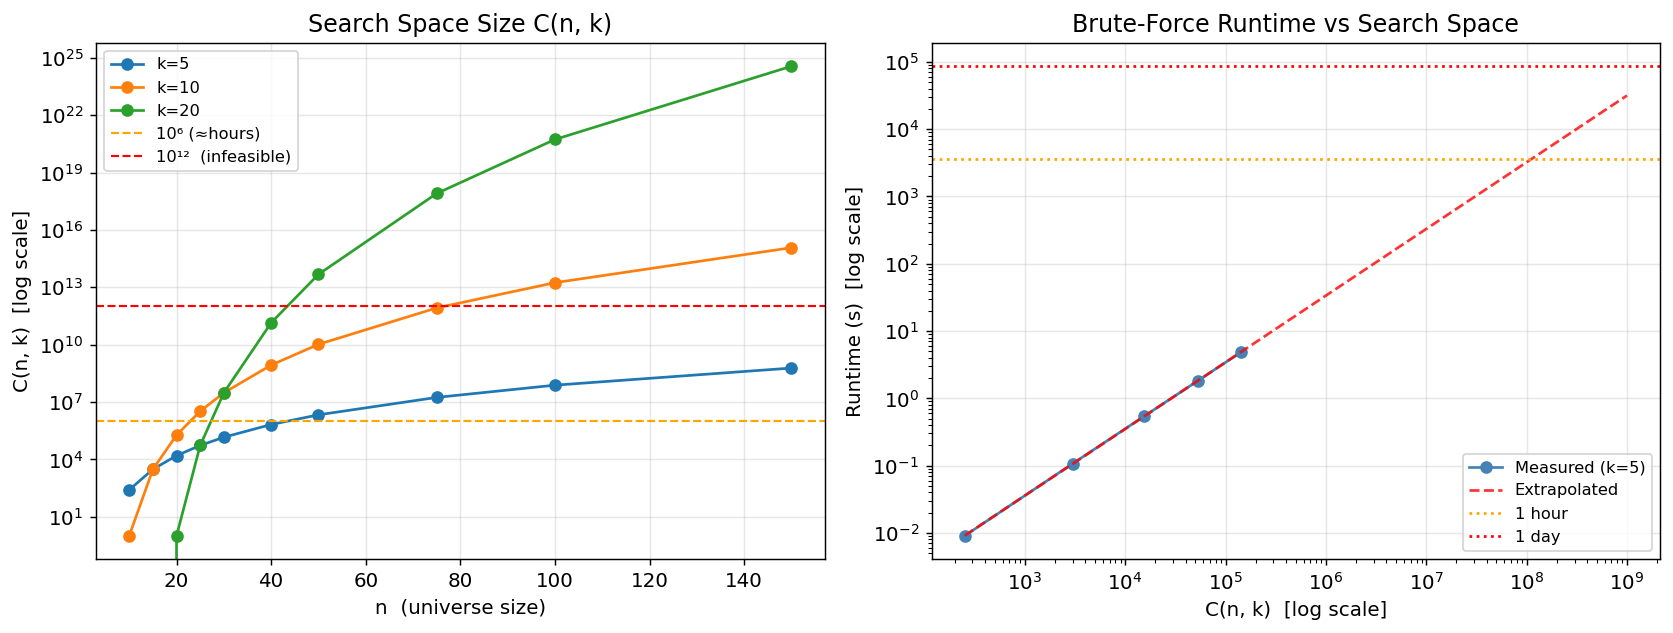

In [8]:
n_range  = [10, 15, 20, 25, 30, 40, 50, 75, 100, 150]
k_values = [5, 10, 20]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for k in k_values:
    counts = [comb(n, k) for n in n_range]
    axes[0].semilogy(n_range, counts, marker='o', label=f'k={k}')
axes[0].axhline(1e6,  color='orange', ls='--', lw=1.2, label='10⁶ (≈hours)')
axes[0].axhline(1e12, color='red',    ls='--', lw=1.2, label='10¹²  (infeasible)')
axes[0].set_xlabel("n  (universe size)")
axes[0].set_ylabel("C(n, k)  [log scale]")
axes[0].set_title("Search Space Size C(n, k)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Actual brute-force timing for small n — time up to n=30 with N=50
timing = []
print("Timing brute force (k=5):")
for n_t in [10, 15, 20, 25, 30]:
    sub, ret, total, rt = brute_force(n_t, 5, mu_all[:n_t], Sigma_all[:n_t,:n_t], SIGMA_SQ_MAX, max_combos=500_000)
    if rt is not None:
        timing.append((n_t, total, rt))
        print(f"  n={n_t}: C(n,5)={total:,}  time={rt:.1f}s")

if len(timing) >= 2:
    ns_t = [r[0] for r in timing]
    cs_t = [r[1] for r in timing]
    ts_t = [r[2] for r in timing]
    axes[1].loglog(cs_t, ts_t, 'o-', color='steelblue', label='Measured (k=5)')
    z = np.polyfit(np.log(cs_t), np.log(ts_t), 1)
    x_ext = np.logspace(np.log10(cs_t[0]), np.log10(1e9), 100)
    axes[1].loglog(x_ext, np.exp(z[1]) * x_ext**z[0], '--', color='red', alpha=0.8, label='Extrapolated')
    axes[1].axhline(3600, color='orange', ls=':', label='1 hour')
    axes[1].axhline(86400, color='red', ls=':', label='1 day')
    axes[1].set_xlabel("C(n, k)  [log scale]")
    axes[1].set_ylabel("Runtime (s)  [log scale]")
    axes[1].set_title("Brute-Force Runtime vs Search Space")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig2_scaling.png")
plt.show()

## 6. Experiment B — Quality Comparison (Brute Force vs Greedy vs SA)

n=30, k=5   C(n,k)=142,506
Tickers: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA', 'META', 'TSLA', 'AVGO', 'AMD', 'ORCL', 'JPM', 'BAC', 'GS', 'WFC', 'MS', 'V', 'MA', 'AXP', 'JNJ', 'UNH', 'PFE', 'MRK', 'ABBV', 'LLY', 'TMO', 'XOM', 'CVX', 'COP', 'SLB', 'EOG']
-------------------------------------------------------


Brute force  ret=41.7868%   time=4.9s
Greedy       ret=40.4864%   time=0.00s   gap=3.11%
SA           ret=41.7868%                   gap=0.00%
SOCP bound   ret=47.7913%  (cardinality gap=12.56%)


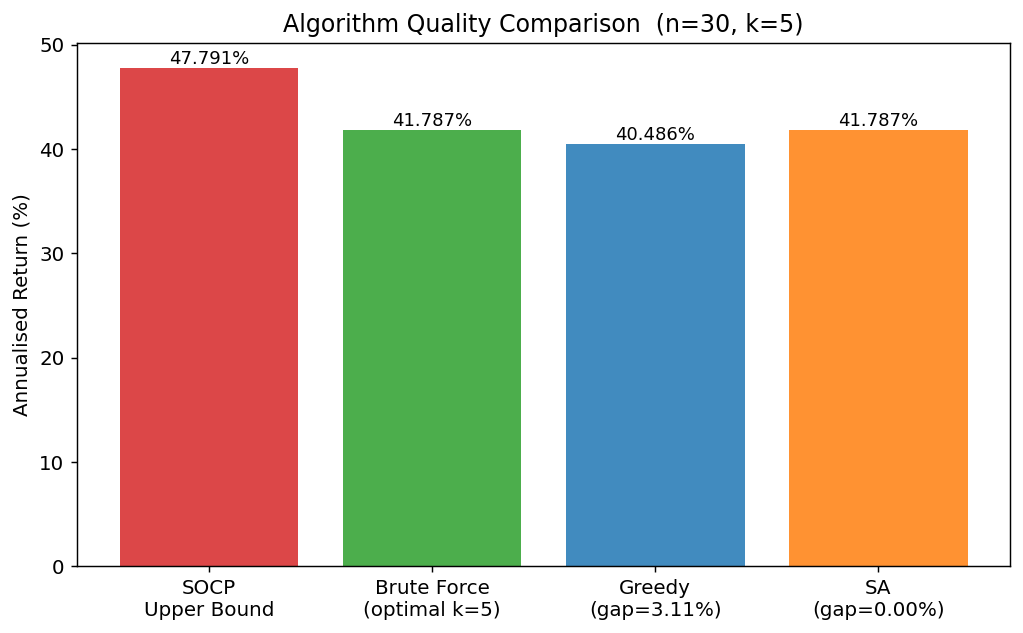

In [9]:
# Fixed 30-stock subset for brute force — same large-caps as the original curated universe
BF_TICKERS = [
    'AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA', 'META', 'TSLA', 'AVGO', 'AMD', 'ORCL',
    'JPM',  'BAC',  'GS',   'WFC',  'MS',   'V',    'MA',   'AXP',
    'JNJ',  'UNH',  'PFE',  'MRK',  'ABBV', 'LLY',  'TMO',
    'XOM',  'CVX',  'COP',  'SLB',  'EOG',
]
bf_idx = [tickers.index(t) for t in BF_TICKERS if t in tickers]
n_B, k_B = len(bf_idx), 5

mu_B    = mu_all[bf_idx]
Sigma_B = Sigma_all[np.ix_(bf_idx, bf_idx)]

print(f"n={n_B}, k={k_B}   C(n,k)={comb(n_B,k_B):,}")
print(f"Tickers: {[tickers[i] for i in bf_idx]}")
print("-"*55)

bf_sub, bf_ret, _, bf_time = brute_force(n_B, k_B, mu_B, Sigma_B, SIGMA_SQ_MAX, max_combos=200_000)
print(f"Brute force  ret={bf_ret:.4%}   time={bf_time:.1f}s")

gr_sub, gr_ret, gr_time = greedy(n_B, k_B, mu_B, Sigma_B, SIGMA_SQ_MAX)
bf_valid = (bf_ret is not None and bf_ret != -np.inf)
gr_gap = 100*(bf_ret - gr_ret)/abs(bf_ret) if (bf_valid and gr_ret is not None) else float('nan')
print(f"Greedy       ret={gr_ret:.4%}   time={gr_time:.2f}s   gap={gr_gap:.2f}%")

sa_sub, sa_ret, sa_hist = simulated_annealing(n_B, k_B, mu_B, Sigma_B, SIGMA_SQ_MAX, n_steps=500, n_restarts=5)
sa_valid = (sa_ret is not None and sa_ret != -np.inf)
sa_gap = 100*(bf_ret - sa_ret)/abs(bf_ret) if (bf_valid and sa_valid) else float('nan')
print(f"SA           ret={sa_ret:.4%}                   gap={sa_gap:.2f}%")

_, ub_ret_small = socp_upper_bound(mu_B, Sigma_B, SIGMA_SQ_MAX)
if ub_ret_small is not None and bf_valid:
    card_gap = 100*(ub_ret_small - bf_ret)/abs(ub_ret_small)
    print(f"SOCP bound   ret={ub_ret_small:.4%}  (cardinality gap={card_gap:.2f}%)")
else:
    card_gap = float('nan')
    ub_display = f"{ub_ret_small:.4%}" if ub_ret_small is not None else "N/A"
    print(f"SOCP bound   ret={ub_display}  (cardinality gap=N/A)")

label_val_col = [
    ('SOCP\nUpper Bound',              ub_ret_small,                          '#d62728'),
    (f'Brute Force\n(optimal k={k_B})', bf_ret if bf_valid else None,         '#2ca02c'),
    (f'Greedy\n(gap={gr_gap:.2f}%)',   gr_ret,                                '#1f77b4'),
    (f'SA\n(gap={sa_gap:.2f}%)',       sa_ret if sa_valid else None,          '#ff7f0e'),
]
valid_bars = [(lbl, val, col) for lbl, val, col in label_val_col if val is not None]

if valid_bars:
    labels = [v[0] for v in valid_bars]
    values = [v[1] for v in valid_bars]
    colors = [v[2] for v in valid_bars]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, [v*100 for v in values], color=colors, alpha=0.85)
    ax.set_ylabel("Annualised Return (%)")
    ax.set_title(f"Algorithm Quality Comparison  (n={n_B}, k={k_B})")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.3%}", ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.savefig("fig3_quality_comparison.png")
    plt.show()

## 7. Experiment C — Simulated Annealing as a Markov Chain on Portfolio Space

SA convergence — varying k (n=462):


  k=5 done, best=49.0716%


  k=10 done, best=57.7155%


  k=20 done, best=68.2401%


  k=50 done, best=84.9103%

SA convergence — varying n (k=10):


  n=20 done, best=32.6775%


  n=50 done, best=46.3146%


  n=462 done, best=57.3342%


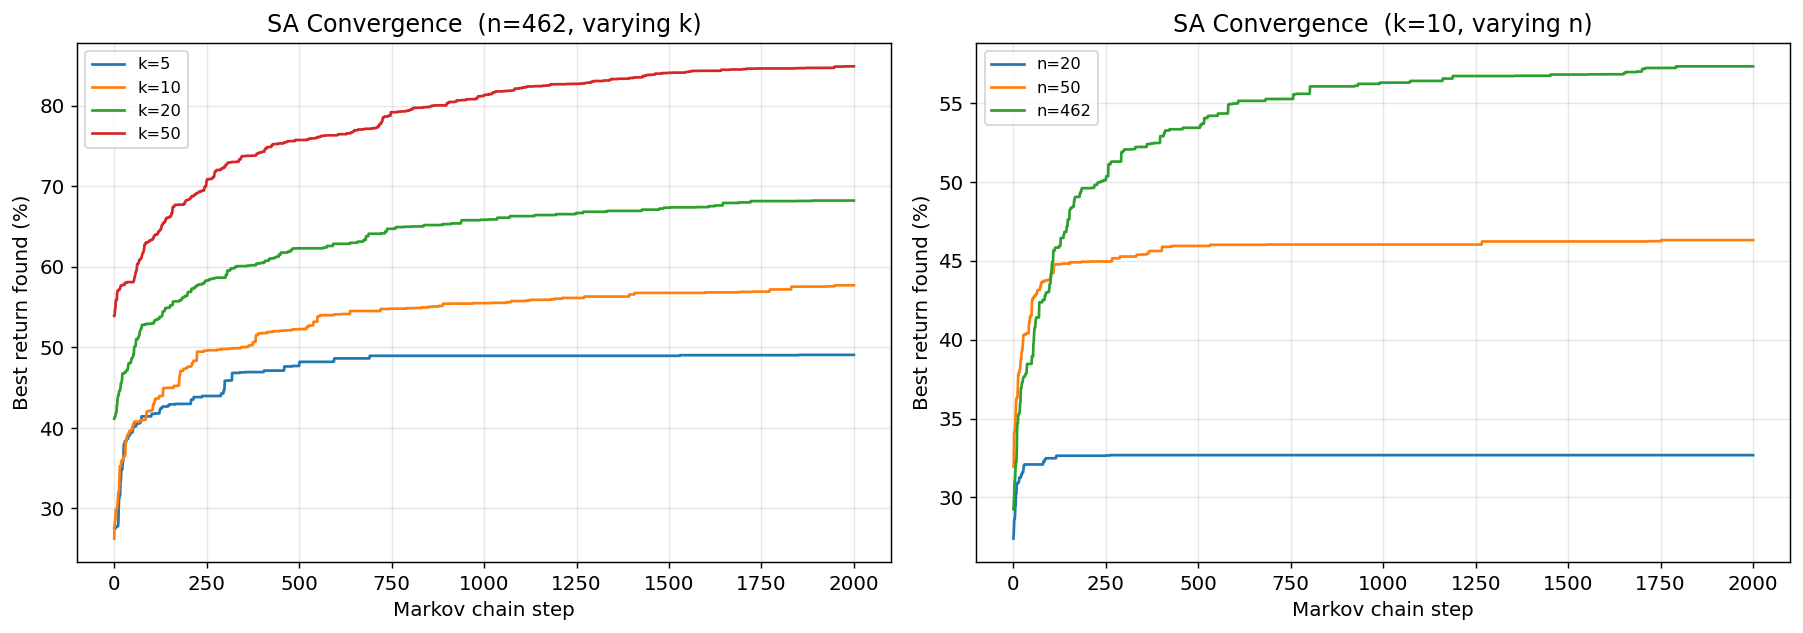

In [10]:
N_STEPS = 2000
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# C1: convergence for different k, fixed n = full universe
n_C = N
k_C_list = [k for k in [5, 10, 20, 50] if k < n_C]
print(f"SA convergence — varying k (n={n_C}):")
for k_c in k_C_list:
    _, _, hist = simulated_annealing(n_C, k_c, mu_all[:n_C], Sigma_all[:n_C,:n_C],
                                     SIGMA_SQ_MAX, n_steps=N_STEPS, n_restarts=3)
    axes[0].plot(np.arange(N_STEPS+1), np.array(hist)*100, label=f'k={k_c}')
    print(f"  k={k_c} done, best={hist[-1]:.4%}")
axes[0].set_xlabel("Markov chain step")
axes[0].set_ylabel("Best return found (%)")
axes[0].set_title(f"SA Convergence  (n={n_C}, varying k)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# C2: convergence for different n, fixed k
k_C2 = min(10, N - 1)
n_C_list = sorted(set([n for n in [10, 20, 50, N] if n <= N and n > k_C2]))
print(f"\nSA convergence — varying n (k={k_C2}):")
for n_c in n_C_list:
    _, _, hist = simulated_annealing(n_c, k_C2, mu_all[:n_c], Sigma_all[:n_c,:n_c],
                                      SIGMA_SQ_MAX, n_steps=N_STEPS, n_restarts=3)
    axes[1].plot(np.arange(N_STEPS+1), np.array(hist)*100, label=f'n={n_c}')
    print(f"  n={n_c} done, best={hist[-1]:.4%}")
axes[1].set_xlabel("Markov chain step")
axes[1].set_ylabel("Best return found (%)")
axes[1].set_title(f"SA Convergence  (k={k_C2}, varying n)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig4_sa_convergence.png")
plt.show()

## 8. Experiment D — Cost of the Cardinality Constraint

SOCP upper bound (n=462): 120.2391%
   k     Greedy         SA  Greedy gap    SA gap
--------------------------------------------------


k:   0%|          | 0/14 [00:00<?, ?it/s]

   1   23.2967%   23.2967%      80.62%    80.62%


   2   39.6649%   39.6649%      67.01%    67.01%


   3   43.4753%   42.6707%      63.84%    64.51%


...

  50   86.8982%   84.3016%      27.73%    29.89%


  75   95.6720%   92.3495%      20.43%    23.20%


 100  101.3914%   97.8009%      15.68%    18.66%


 150  109.4602%  106.5537%       8.96%    11.38%


 200  114.5317%  111.5957%       4.75%     7.19%


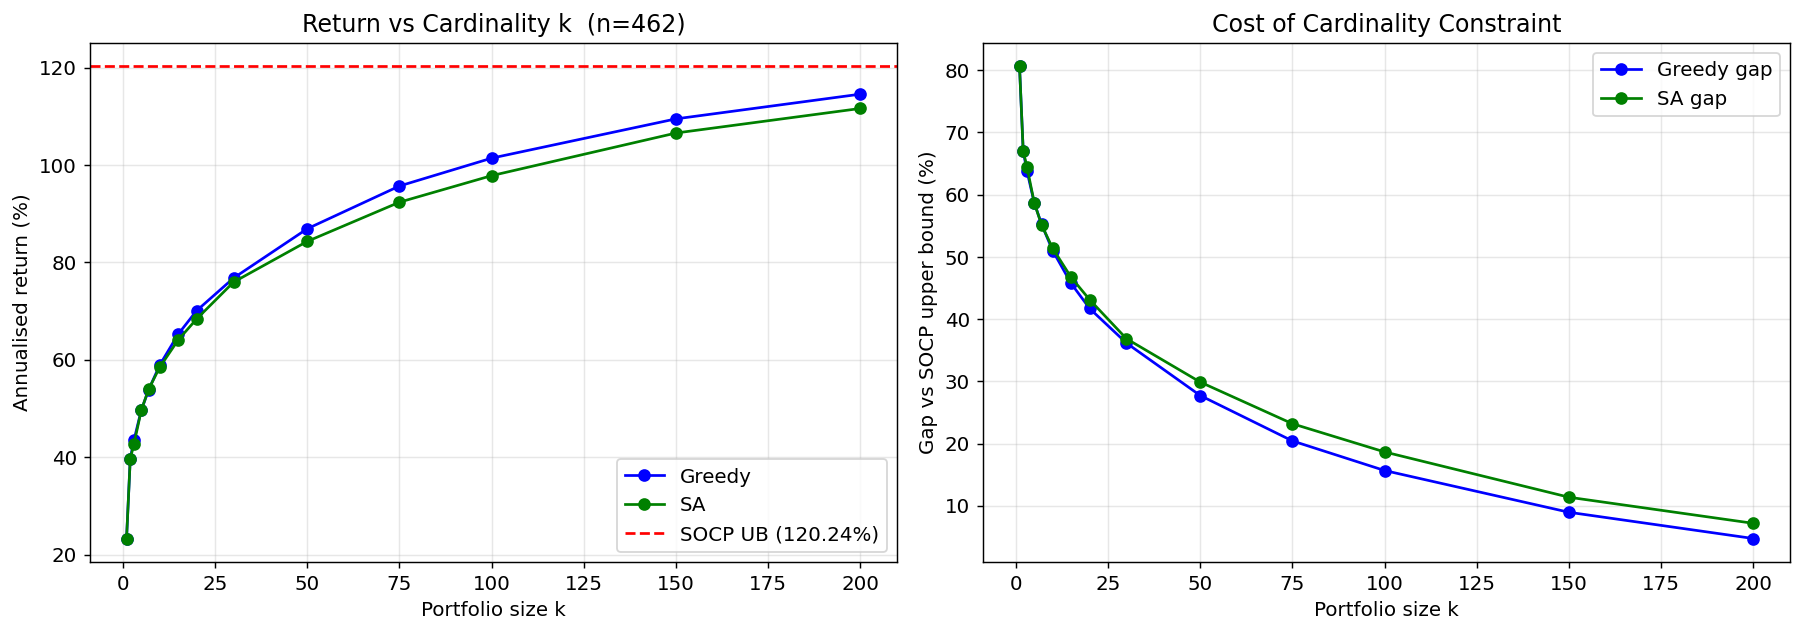

In [11]:
n_D = N  # = 462
k_D_list = [k for k in [1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 75, 100, 150, 200] if k < n_D]

_, ub_D = socp_upper_bound(mu_all[:n_D], Sigma_all[:n_D,:n_D], SIGMA_SQ_MAX)
if ub_D is None:
    print(f"SOCP upper bound (n={n_D}): INFEASIBLE — check SIGMA_SQ_MAX")
else:
    print(f"SOCP upper bound (n={n_D}): {ub_D:.4%}")

greedy_rets, sa_rets = [], []
print(f"{'k':>4}  {'Greedy':>9}  {'SA':>9}  {'Greedy gap':>10}  {'SA gap':>8}")
print("-"*50)
for k_d in tqdm(k_D_list, desc="k"):
    _, g, _ = greedy(n_D, k_d, mu_all[:n_D], Sigma_all[:n_D,:n_D], SIGMA_SQ_MAX)
    _, s, _ = simulated_annealing(n_D, k_d, mu_all[:n_D], Sigma_all[:n_D,:n_D],
                                   SIGMA_SQ_MAX, n_steps=1500, n_restarts=2)
    g = g or 0.0; s = s or 0.0
    greedy_rets.append(g); sa_rets.append(s)
    if ub_D:
        print(f"{k_d:>4}  {g:>9.4%}  {s:>9.4%}  {100*(ub_D-g)/ub_D:>9.2f}%  {100*(ub_D-s)/ub_D:>7.2f}%")
    else:
        print(f"{k_d:>4}  {g:>9.4%}  {s:>9.4%}  (no UB)")

if ub_D:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(k_D_list, [r*100 for r in greedy_rets], 'b-o', label='Greedy')
    axes[0].plot(k_D_list, [r*100 for r in sa_rets],     'g-o', label='SA')
    axes[0].axhline(ub_D*100, color='red', ls='--', label=f'SOCP UB ({ub_D:.2%})')
    axes[0].set_xlabel("Portfolio size k")
    axes[0].set_ylabel("Annualised return (%)")
    axes[0].set_title(f"Return vs Cardinality k  (n={n_D})")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(k_D_list, [100*(ub_D-g)/ub_D for g in greedy_rets], 'b-o', label='Greedy gap')
    axes[1].plot(k_D_list, [100*(ub_D-s)/ub_D for s in sa_rets],     'g-o', label='SA gap')
    axes[1].set_xlabel("Portfolio size k")
    axes[1].set_ylabel("Gap vs SOCP upper bound (%)")
    axes[1].set_title("Cost of Cardinality Constraint")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("fig5_gap_vs_k.png")
    plt.show()

## 9. Experiment E — Constraint Tightness vs Problem Hardness

Enumerating 324,632 portfolios (n=35, k=5)...


constraint sweep:   0%|          | 0/25 [00:00<?, ?it/s]

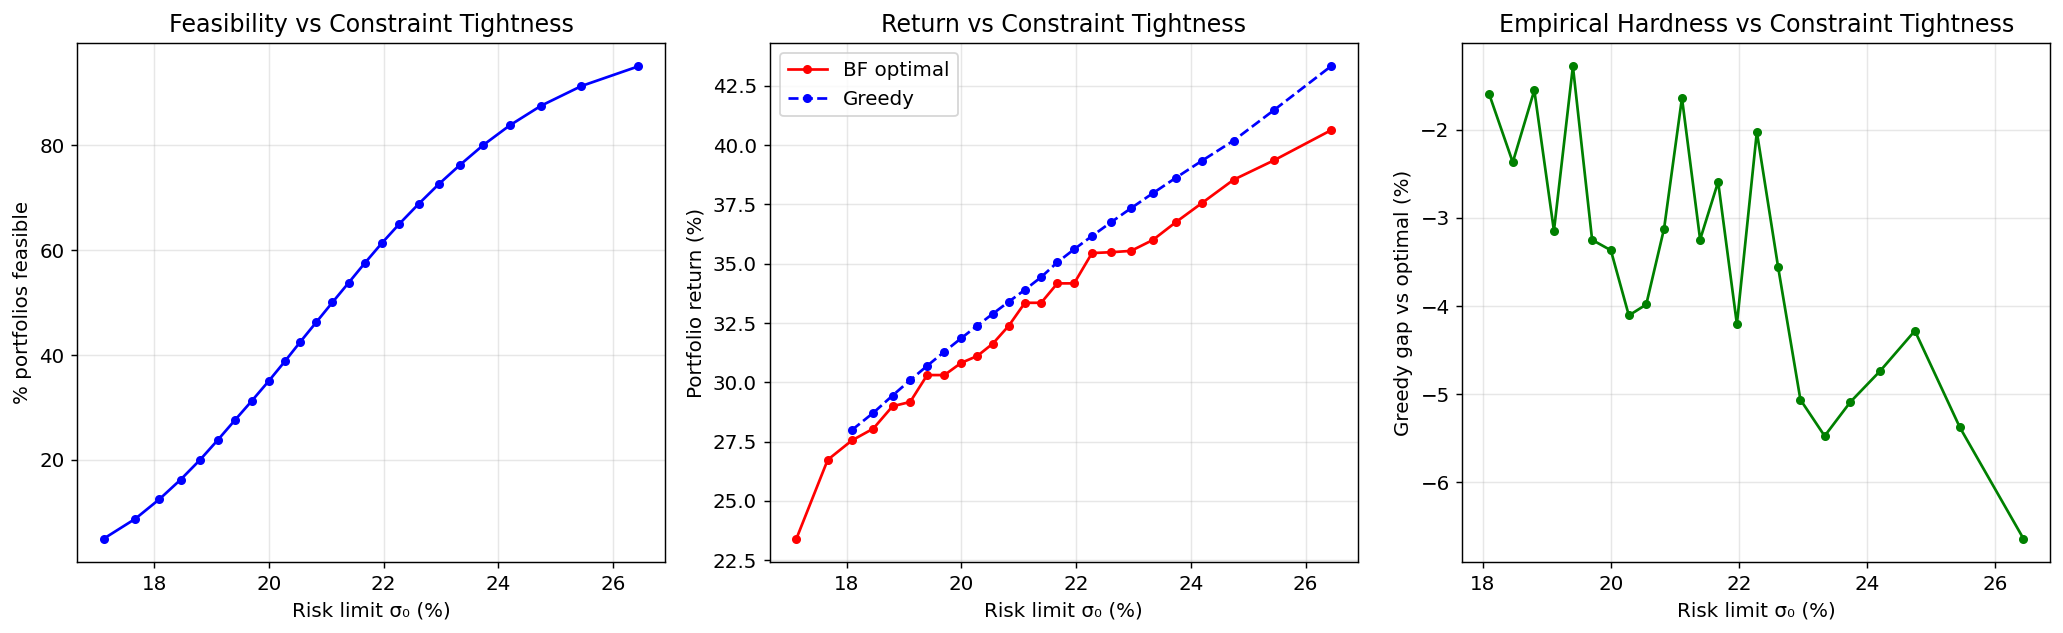

In [12]:
# Fixed 35-stock subset for the constraint sweep — first 35 of the curated large-caps
EF_TICKERS = [
    'AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA', 'META', 'TSLA', 'AVGO', 'AMD', 'ORCL',
    'JPM',  'BAC',  'GS',   'WFC',  'MS',   'V',    'MA',   'AXP',
    'JNJ',  'UNH',  'PFE',  'MRK',  'ABBV', 'LLY',  'TMO',
    'XOM',  'CVX',  'COP',  'SLB',  'EOG',
    'PG',   'KO',   'PEP',  'WMT',  'COST',
]
ef_idx = [tickers.index(t) for t in EF_TICKERS if t in tickers]
n_E, k_E = len(ef_idx), 5

mu_E    = mu_all[ef_idx]
Sigma_E = Sigma_all[np.ix_(ef_idx, ef_idx)]

all_subs = list(combinations(range(n_E), k_E))
print(f"Enumerating {len(all_subs):,} portfolios (n={n_E}, k={k_E})...")

all_rets_eq, all_vars_eq = [], []
for sub in all_subs:
    idx = list(sub)
    w_eq = np.ones(k_E) / k_E
    all_rets_eq.append(mu_E[idx] @ w_eq)
    all_vars_eq.append(w_eq @ Sigma_E[np.ix_(idx, idx)] @ w_eq)
all_rets_eq = np.array(all_rets_eq)
all_vars_eq = np.array(all_vars_eq)

sigma_sq_grid = np.percentile(all_vars_eq, np.linspace(5, 95, 25))
pct_feasible, opt_rets, gr_rets, gaps = [], [], [], []

for sig_sq in tqdm(sigma_sq_grid, desc="constraint sweep"):
    mask = all_vars_eq <= sig_sq
    pct_feasible.append(mask.mean() * 100)
    if not mask.any():
        opt_rets.append(np.nan); gr_rets.append(np.nan); gaps.append(np.nan)
        continue
    opt_ret = all_rets_eq[mask].max()
    opt_rets.append(opt_ret)
    _, g_ret, _ = greedy(n_E, k_E, mu_E, Sigma_E, sig_sq)
    gr_rets.append(g_ret if g_ret is not None else np.nan)
    if g_ret is not None and opt_ret:
        gaps.append(100*(opt_ret - g_ret)/abs(opt_ret))
    else:
        gaps.append(np.nan)

vols_pct = np.sqrt(sigma_sq_grid) * 100
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(vols_pct, pct_feasible, 'b-o', ms=4)
axes[0].set_xlabel("Risk limit σ₀ (%)")
axes[0].set_ylabel("% portfolios feasible")
axes[0].set_title("Feasibility vs Constraint Tightness")
axes[0].grid(True, alpha=0.3)

axes[1].plot(vols_pct, np.array(opt_rets)*100, 'r-o', ms=4, label='BF optimal')
axes[1].plot(vols_pct, np.array(gr_rets)*100,  'b--o', ms=4, label='Greedy')
axes[1].set_xlabel("Risk limit σ₀ (%)")
axes[1].set_ylabel("Portfolio return (%)")
axes[1].set_title("Return vs Constraint Tightness")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(vols_pct, gaps, 'g-o', ms=4)
axes[2].set_xlabel("Risk limit σ₀ (%)")
axes[2].set_ylabel("Greedy gap vs optimal (%)")
axes[2].set_title("Empirical Hardness vs Constraint Tightness")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig6_constraint_tightness.png")
plt.show()

## 10. Experiment F — Random Sampling Discovery Curve

Precomputing SOCP values for 324,632 subsets (n=35, k=5)...


  0%|          | 0/324632 [00:00<?, ?it/s]

Feasible subsets: 323,027 / 324,632  (99.5%)
Optimal return: 43.0290%



Fraction of search space needed (mean over trials):
  90% of optimal: sample 0.50% of C(n,k)
  95% of optimal: sample 0.50% of C(n,k)
  99% of optimal: sample 34.17% of C(n,k)
  100% of optimal: sample 100.00% of C(n,k)


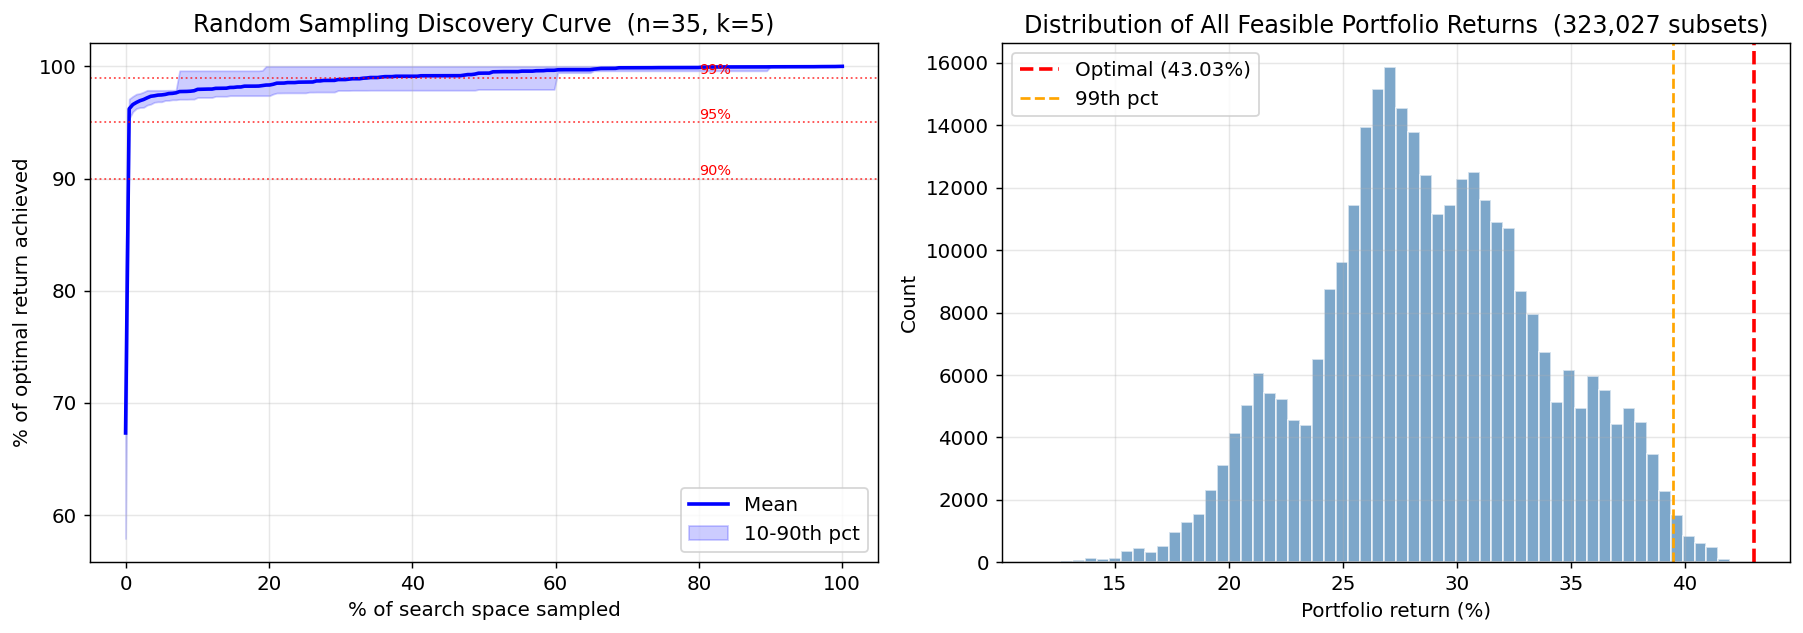

In [13]:
# Reuse the same 35-stock curated subset defined in Experiment E
n_F, k_F = n_E, 5
N_TRIALS = 50
total_combos = comb(n_F, k_F)
all_subs_F = list(combinations(range(n_F), k_F))

print(f"Precomputing SOCP values for {total_combos:,} subsets (n={n_F}, k={k_F})...")
sub_vals = []
for sub in tqdm(all_subs_F):
    _, ret = solve_subset(sub, mu_E, Sigma_E, SIGMA_SQ_MAX)
    sub_vals.append(ret if ret is not None else -np.inf)
sub_vals = np.array(sub_vals)

feasible_mask = sub_vals > -np.inf
n_feasible = feasible_mask.sum()
print(f"Feasible subsets: {n_feasible:,} / {total_combos:,}  ({100*n_feasible/total_combos:.1f}%)")

if n_feasible == 0:
    print("No feasible subset found — SIGMA_SQ_MAX is too tight. Skipping Experiment F.")
else:
    optimal_ret_F = sub_vals.max()
    print(f"Optimal return: {optimal_ret_F:.4%}")

    fracs = np.linspace(0, 1, 200)
    sample_counts = (fracs * total_combos).astype(int)
    sample_counts[0] = 1

    all_curves = np.zeros((N_TRIALS, len(sample_counts)))
    for trial in range(N_TRIALS):
        perm = np.random.permutation(total_combos)
        for j, sc in enumerate(sample_counts):
            all_curves[trial, j] = sub_vals[perm[:sc]].max()

    mean_curve = all_curves.mean(axis=0) / optimal_ret_F * 100
    p10 = np.percentile(all_curves, 10, axis=0) / optimal_ret_F * 100
    p90 = np.percentile(all_curves, 90, axis=0) / optimal_ret_F * 100

    thresholds = [90, 95, 99, 100]
    print("\nFraction of search space needed (mean over trials):")
    for thr in thresholds:
        idx_thr = np.searchsorted(mean_curve, thr)
        if idx_thr < len(fracs):
            print(f"  {thr}% of optimal: sample {fracs[idx_thr]*100:.2f}% of C(n,k)")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(fracs*100, mean_curve, 'b-', lw=2, label='Mean')
    axes[0].fill_between(fracs*100, p10, p90, alpha=0.2, color='blue', label='10-90th pct')
    for thr in [90, 95, 99]:
        axes[0].axhline(thr, color='red', ls=':', lw=1, alpha=0.7)
        axes[0].text(80, thr+0.3, f'{thr}%', color='red', fontsize=8)
    axes[0].set_xlabel("% of search space sampled")
    axes[0].set_ylabel("% of optimal return achieved")
    axes[0].set_title(f"Random Sampling Discovery Curve  (n={n_F}, k={k_F})")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    feasible_vals = sub_vals[feasible_mask]
    axes[1].hist(feasible_vals*100, bins=min(60, n_feasible), color='steelblue', alpha=0.7, edgecolor='white')
    axes[1].axvline(optimal_ret_F*100, color='red', ls='--', lw=2, label=f'Optimal ({optimal_ret_F:.2%})')
    axes[1].axvline(np.percentile(feasible_vals, 99)*100, color='orange', ls='--', lw=1.5, label='99th pct')
    axes[1].set_xlabel("Portfolio return (%)")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Distribution of All Feasible Portfolio Returns  ({n_feasible:,} subsets)")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("fig7_random_sampling.png")
    plt.show()

## 11. Summary

In [14]:
def _fmt(v):
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return "N/A"
    return f"{v:.4%}"

def _fmt_gap(g):
    if g is None or (isinstance(g, float) and not np.isfinite(g)):
        return "N/A"
    return f"{g:.2f}%"

print("="*65)
print("SUMMARY")
print("="*65)
print(f"Universe          : N={N} stocks, T={T} trading days")
print(f"Risk limit sigma_0 : {np.sqrt(SIGMA_SQ_MAX):.2%}  (25th pct of individual stock vols)")
print()
print("Key results:")
print(f"  SOCP upper bound (no cardinality) : {_fmt(ret_ub)}")
print(f"  Brute force optimal (n={n_B}, k={k_B})   : {_fmt(bf_ret)}")
print(f"  Greedy (n={n_B}, k={k_B})                : {_fmt(gr_ret)}  (gap {_fmt_gap(gr_gap)})")
print(f"  SA     (n={n_B}, k={k_B})                : {_fmt(sa_ret)}  (gap {_fmt_gap(sa_gap)})")
print()
print("Figures saved:")
for name in [
    "fig1_socp_weights.png",
    "fig2_scaling.png",
    "fig3_quality_comparison.png",
    "fig4_sa_convergence.png",
    "fig5_gap_vs_k.png",
    "fig6_constraint_tightness.png",
    "fig7_random_sampling.png",
]:
    print(f"  {name}")

SUMMARY
Universe          : N=462 stocks, T=2854 trading days
Risk limit sigma_0 : 25.64%  (25th pct of individual stock vols)

Key results:
  SOCP upper bound (no cardinality) : 120.2391%
  Brute force optimal (n=30, k=5)   : 41.7868%
  Greedy (n=30, k=5)                : 40.4864%  (gap 3.11%)
  SA     (n=30, k=5)                : 41.7868%  (gap 0.00%)

Figures saved:
  fig1_socp_weights.png
  fig2_scaling.png
  fig3_quality_comparison.png
  fig4_sa_convergence.png
  fig5_gap_vs_k.png
  fig6_constraint_tightness.png
  fig7_random_sampling.png
